In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('/content/Synthetic.csv')

In [10]:
df.head()

,Unnamed: 0,X,Y
0,0,37.454012,126.746701
1,1,95.071431,293.927975
2,2,73.199394,225.441700
3,3,59.865848,183.586508
4,4,15.601864,39.020372


In [11]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [12]:
df.head()

,X,Y
0,37.454012,126.746701
1,95.071431,293.927975
2,73.199394,225.441700
3,59.865848,183.586508
4,15.601864,39.020372


In [13]:
x = df['X'].values
y = df['Y'].values

x = (x - np.mean(x)) / np.std(x)

In [14]:
x = x.reshape(1, -1)
y = y.reshape(-1, 1)

In [15]:
noOfFeatures, m = x.shape

In [16]:
class SLR:
    def __init__(self, learning_rate=0.0001, epochs=10000, tolerance=0.001):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.tolerance = tolerance
        self.theta_0 = None
        self.theta_1 = None
        self.losses = []

    def fit(self, x, y):
        m = x.shape[1]
        self.theta_0 = np.random.randn(1, 1)
        self.theta_1 = np.random.randn(1, 1)

        loss = 1
        self.losses = []
        epoch = 1

        while epoch <= self.epochs and loss > self.tolerance:
            y_hat = self.theta_0 * x + self.theta_1
            loss = 0.5 * np.mean((y_hat.T - y) ** 2)

            d_theta_0 = 1 / m * np.dot(x, (y_hat.T - y))
            d_theta_1 = 1 / m * np.sum(y_hat.T - y)

            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1

            self.losses.append(loss)
            epoch += 1

        return self

    def predict(self, x):
        return self.theta_0 * x + self.theta_1


(1, 1) (1, 1)
(1, 1) (1, 1)


Text(0, 0.5, 'Loss (MSE)')

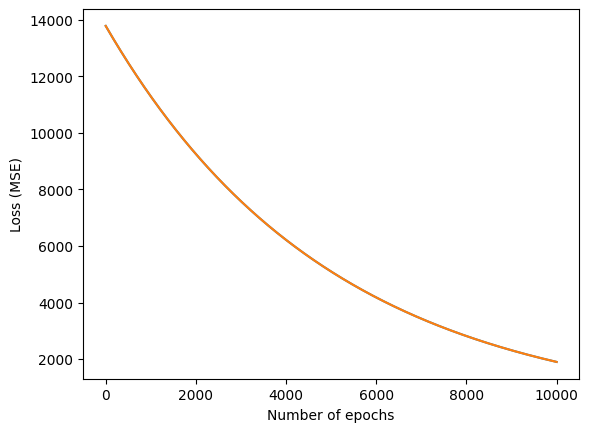

In [17]:
model = SLR(learning_rate=0.0001, epochs=10000, tolerance=0.001)
model.fit(x, y)

print(model.theta_0.shape, model.theta_1.shape)

plt.plot(model.losses)
plt.xlabel("Number of epochs")
plt.ylabel("Loss (MSE)")

print(model.theta_0.shape, model.theta_1.shape)

plt.plot(model.losses)
plt.xlabel("Number of epochs")
plt.ylabel("Loss (MSE)")